In [1]:
import pandas as pd
import numpy as np
import sqlalchemy
import seaborn as sns
import requests
import matplotlib.pyplot as plt 
from IPython.display import display
from pathlib import Path
import pandas as pd
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import numpy as np


THRESHHOLD_MISSING_SAMPLES_PCT = 5

CONSUMPTION_PATH = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses\Dataset\merged_imp_csv")
BASE_PATH = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses")
METADATA_PATH = BASE_PATH / "filtered_metadata.csv"
TEMP_BATCH_PATH = BASE_PATH / "municipality_temp_batches"
OUT_FILE = BASE_PATH / "municipality_daily_consumption.csv"
MIN_USERS = 100

In [ ]:

# pip install holidays
try:
    import holidays as hols
    HAS_HOLIDAYS = True
except ImportError:
    print("'holidays' package not found. Run: pip install holidays")
    print("Spain public holidays will be skipped.\n")
    HAS_HOLIDAYS = False

# ─────────────────────────────────────────
# Paths
# ─────────────────────────────────────────
CONSUMPTION_PATH = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses\Dataset\merged_imp_csv")
BASE_PATH        = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses")

METADATA_PATH   = BASE_PATH / "filtered_metadata.csv"
TEMP_BATCH_PATH = BASE_PATH / "municipality_temp_batches"
OUT_FILE        = BASE_PATH / "municipality_daily_features.csv"

TEMP_BATCH_PATH.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────
# Load metadata
# ─────────────────────────────────────────
metadata = pd.read_csv(METADATA_PATH)
metadata.columns = metadata.columns.str.strip().str.lower()

if "user" not in metadata.columns or "municipality" not in metadata.columns:
    raise ValueError("Metadata must contain 'user' and 'municipality' columns.")

metadata = metadata[["user", "municipality"]].dropna(subset=["user", "municipality"])
metadata["user"] = metadata["user"].astype(str).str.strip()

print("Metadata loaded:")
print(metadata.head())


# =============================================================
# FEATURE HELPERS
# =============================================================

def add_calendar_features(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    """
    Adds calendar columns used by forecasting models:
      day_of_week, is_weekend, month, quarter, week_of_year,
      is_holiday_es (Spain), is_bridge_day
    """
    d = df[date_col]

    df["day_of_week"]  = d.dt.dayofweek
    df["is_weekend"]   = d.dt.dayofweek >= 5
    df["month"]        = d.dt.month
    df["quarter"]      = d.dt.quarter
    df["week_of_year"] = d.dt.isocalendar().week.astype(int)

    if HAS_HOLIDAYS:
        years = d.dt.year.unique().tolist()
        es_holidays = set()
        for y in years:
            es_holidays.update(hols.Spain(years=y).keys())

        df["is_holiday_es"] = d.dt.date.isin(es_holidays)

        holiday_dates = pd.to_datetime(sorted(es_holidays))
        bridge = set()
        for h in holiday_dates:
            if h.weekday() == 1:
                bridge.add((h - pd.Timedelta(days=1)).date())
            elif h.weekday() == 3:
                bridge.add((h + pd.Timedelta(days=1)).date())
        df["is_bridge_day"] = d.dt.date.isin(bridge)
    else:
        df["is_holiday_es"] = False
        df["is_bridge_day"] = False

    return df


def add_lag_features(df: pd.DataFrame,
                     group_col: str = "municipality",
                     value_col: str = "avg_kwh_per_user") -> pd.DataFrame:
    df = df.sort_values([group_col, "date"]).copy()
    grp = df.groupby(group_col)[value_col]

    df["lag_1d"]  = grp.shift(1)
    df["lag_7d"]  = grp.shift(7)
    df["lag_14d"] = grp.shift(14)
    df["lag_30d"] = grp.shift(30)

    df["roll7_mean"]  = grp.transform(lambda s: s.shift(1).rolling(7,  min_periods=3).mean())
    df["roll7_std"]   = grp.transform(lambda s: s.shift(1).rolling(7,  min_periods=3).std())
    df["roll30_mean"] = grp.transform(lambda s: s.shift(1).rolling(30, min_periods=7).mean())

    df["roll7_ratio"] = np.where(
        df["roll7_mean"].notna() & (df["roll7_mean"] != 0),
        df[value_col] / df["roll7_mean"],
        np.nan
    )
    df["wow_change"] = np.where(
        df["lag_7d"].notna() & (df["lag_7d"] != 0),
        (df[value_col] - df["lag_7d"]) / df["lag_7d"] * 100,
        np.nan
    )
    df["dod_change"] = np.where(
        df["lag_1d"].notna() & (df["lag_1d"] != 0),
        (df[value_col] - df["lag_1d"]) / df["lag_1d"] * 100,
        np.nan
    )
    return df


def add_normalization_features(
    df: pd.DataFrame,
    group_col: str = "municipality",
    value_col: str = "avg_kwh_per_user"
) -> pd.DataFrame:
    mu  = df.groupby(group_col)[value_col].transform("mean")
    sig = df.groupby(group_col)[value_col].transform("std")

    df["zscore_municipality"] = np.where(
        sig.notna() & (sig != 0),
        (df[value_col] - mu) / sig,
        0.0
    )
    df["pct_rank_global"] = df[value_col].rank(pct=True).round(4)
    df["log_kwh"]         = np.log1p(df[value_col])
    return df


# =============================================================
# Process one CSV file (user level)
# =============================================================

def process_one_file(file: Path, metadata_df: pd.DataFrame):
    try:
        df = pd.read_csv(file, usecols=["timestamp", "kWh"], engine="python", on_bad_lines="skip")
        df.columns = df.columns.str.strip().str.lower()
        df["user"] = file.stem

        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df["kwh"]       = pd.to_numeric(df["kwh"], errors="coerce")
        df = df.dropna(subset=["timestamp", "kwh", "user"])
        if df.empty:
            return None

        df["date"] = df["timestamp"].dt.floor("D")

        daily = (
            df.groupby(["user", "date"], as_index=False)["kwh"]
              .mean()
              .rename(columns={"kwh": "daily_kwh"})
        )
        daily["user"]       = daily["user"].astype(str).str.strip()
        daily["is_weekend"] = daily["date"].dt.dayofweek >= 5

        daily = daily.merge(metadata_df, on="user", how="left")
        daily = daily.dropna(subset=["municipality"])
        if daily.empty:
            return None

        return daily[["municipality", "date", "user", "daily_kwh", "is_weekend"]]

    except Exception as e:
        print(f"Error processing {file.name}: {e}")
        return None


# =============================================================
# Batch processing
# =============================================================

files = list(CONSUMPTION_PATH.glob("*.csv"))
print(f"Found {len(files)} files")

batch_size    = 500
batch_num     = 0
current_batch = []

for i, file in enumerate(files, start=1):
    part = process_one_file(file, metadata)
    if part is not None:
        current_batch.append(part)

    if i % batch_size == 0 or i == len(files):
        if current_batch:
            batch_num += 1
            batch_df   = pd.concat(current_batch, ignore_index=True)
            batch_file = TEMP_BATCH_PATH / f"user_daily_batch_{batch_num:03d}.csv"
            batch_df.to_csv(batch_file, index=False)
            print(f"Saved batch {batch_num}: {batch_file} ({len(batch_df)} rows)")
            current_batch = []
        print(f"Processed {i}/{len(files)} files")


# =============================================================
# Combine batches + municipality aggregation
# =============================================================

batch_files = list(TEMP_BATCH_PATH.glob("user_daily_batch_*.csv"))
if not batch_files:
    raise ValueError("No batch files found.")

print(f"\nCombining {len(batch_files)} batch files...")

all_batches = []
for bf in batch_files:
    tmp = pd.read_csv(bf)
    tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
    all_batches.append(tmp)

user_daily = pd.concat(all_batches, ignore_index=True)

municipality_daily = (
    user_daily.groupby(["municipality", "date"])
    .agg(
        avg_kwh=("daily_kwh", "mean"),
        std_kwh=("daily_kwh", "std"),
        total_kwh=("daily_kwh", "sum"),
        n_users=("user", "nunique"),
        is_weekend=("is_weekend", "first"),
    )
    .reset_index()
    .sort_values(["municipality", "date"])
)

municipality_daily["avg_kwh_per_user"] = (
    municipality_daily["total_kwh"] / municipality_daily["n_users"]
)


# =============================================================
# Feature engineering (municipality level)
# =============================================================

print("Adding calendar features ...")
municipality_daily = add_calendar_features(municipality_daily, date_col="date")

print("Adding lag / rolling features ...")
municipality_daily = add_lag_features(municipality_daily)

print("Adding normalisation features ...")
municipality_daily = add_normalization_features(municipality_daily)

municipality_daily.to_csv(OUT_FILE, index=False)

print(f"\nSaved: {OUT_FILE}")
print(f"Shape: {municipality_daily.shape}")
print(municipality_daily.head())
print("\nColumns:")
for col in municipality_daily.columns:
    print(f"  {col}")


In [ ]:
# from pathlib import Path
# import pandas as pd

# CONSUMPTION_PATH = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses\Dataset\merged_imp_csv")
# BASE_PATH = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses")

# METADATA_PATH = BASE_PATH / "filtered_metadata.csv"
# TEMP_BATCH_PATH = BASE_PATH / "sector_temp_batches"
# OUT_FILE = BASE_PATH / "sector_daily_consumption.csv"

# TEMP_BATCH_PATH.mkdir(parents=True, exist_ok=True)

# # -----------------------------
# # Load metadata
# # -----------------------------
# metadata = pd.read_csv(METADATA_PATH)
# metadata.columns = metadata.columns.str.strip().str.lower()

# if "user" not in metadata.columns or "sector" not in metadata.columns:
#     raise ValueError("Metadata must contain 'user' and 'sector' columns.")

# metadata = metadata[["user", "sector"]].dropna(subset=["user", "sector"])
# metadata["user"] = metadata["user"].astype(str).str.strip()
# metadata["sector"] = metadata["sector"].astype(str).str.strip()

# print("Metadata loaded:")
# print(metadata.head())


# # -----------------------------
# # Process one file
# # -----------------------------
# def process_one_file(file: Path, metadata_df: pd.DataFrame):
#     try:
#         # only read the columns we need
#         df = pd.read_csv(
#             file,
#             usecols=["timestamp", "kWh"],
#             engine="python",
#             on_bad_lines="skip"
#         )

#         # standardize names
#         df.columns = df.columns.str.strip().str.lower()

#         # user comes from filename
#         df["user"] = file.stem

#         # clean types
#         df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
#         df["kwh"] = pd.to_numeric(df["kwh"], errors="coerce")
#         df["user"] = df["user"].astype(str).str.strip()

#         df = df.dropna(subset=["timestamp", "kwh", "user"])
#         if df.empty:
#             return None

#         df["date"] = df["timestamp"].dt.floor("D")
#         # Only keep users in sector "Household production"

#         # daily mean per user
#         daily = (
#             df.groupby(["user", "date"], as_index=False)["kwh"]
#               .mean()
#               .rename(columns={"kwh": "daily_kwh"})
#         )

#         # merge sector from metadata
#         daily = daily.merge(metadata_df, on="user", how="left")
#         daily = daily[daily["sector"] == "Household production"]
#         daily = daily.dropna(subset=["sector"])

#         if daily.empty:
#             return None

#         return daily[["sector", "date", "user", "daily_kwh"]]

#     except Exception as e:
#         print(f"Error processing {file.name}: {e}")
#         return None


# # -----------------------------
# # Process files in batches
# # -----------------------------
# files = list(CONSUMPTION_PATH.glob("*.csv"))
# print(f"Found {len(files)} files")

# batch_size = 500
# batch_num = 0
# current_batch = []

# for i, file in enumerate(files, start=1):
#     part = process_one_file(file, metadata)

#     if part is not None:
#         current_batch.append(part)

#     if i % batch_size == 0 or i == len(files):
#         if current_batch:
#             batch_num += 1
#             batch_df = pd.concat(current_batch, ignore_index=True)

#             batch_file = TEMP_BATCH_PATH / f"user_daily_batch_{batch_num:03d}.csv"
#             batch_df.to_csv(batch_file, index=False)

#             print(f"Saved batch {batch_num}: {batch_file} ({len(batch_df)} rows)")
#             current_batch = []

#         print(f"Processed {i}/{len(files)} files")


# # -----------------------------
# # Combine all batch files
# # -----------------------------
# batch_files = list(TEMP_BATCH_PATH.glob("user_daily_batch_*.csv"))
# if not batch_files:
#     raise ValueError("No batch files were created. Check metadata user matches.")

# print(f"Combining {len(batch_files)} batch files...")

# all_batches = []
# for bf in batch_files:
#     df = pd.read_csv(bf)
#     df["date"] = pd.to_datetime(df["date"], errors="coerce")
#     all_batches.append(df)

# user_daily = pd.concat(all_batches, ignore_index=True)

# sector_daily = (
#     user_daily.groupby(["sector", "date"])
#     .agg(
#         avg_kwh=("daily_kwh", "mean"),
#         std_kwh=("daily_kwh", "std"),
#         n_users=("user", "nunique")
#     )
#     .reset_index()
#     .sort_values(["sector", "date"])
# )

# sector_daily.to_csv(OUT_FILE, index=False)

# print(f"\nSaved final file: {OUT_FILE}")
# print(sector_daily.head())

In [ ]:
municipality_daily = pd.read_csv(OUT_FILE, parse_dates=["date"])
# Filter out municipalities where more than 10% of days have less than 100 users
def filter_municipalities_by_user_threshold(df, min_users=100, max_pct_below=0.10):
    result = []
    for muni, group in df.groupby('municipality'):
        pct_below = (group['n_users'] < min_users).mean()
        if pct_below <= max_pct_below:
            result.append(group)
    if result:
        return pd.concat(result, ignore_index=True)
    else:
        return pd.DataFrame(columns=df.columns)

municipality_daily = filter_municipalities_by_user_threshold(municipality_daily, min_users=100, max_pct_below=0.10)
print(municipality_daily.head())

  municipality       date   avg_kwh   std_kwh  n_users  season  is_weekend  \
0       Bilbao 2017-05-28  0.126609  0.072134        7  Spring        True   
1       Bilbao 2017-05-29  0.152674  0.093815       11  Spring       False   
2       Bilbao 2017-05-30  0.195725  0.153786       60  Spring       False   
3       Bilbao 2017-05-31  0.210895  0.244422      678  Spring       False   
4       Bilbao 2017-06-01  0.213528  0.250373      683  Summer       False   

   day_of_week   day_name  month  ... roll7_mean  roll7_std  roll30_mean  \
0            6     Sunday      5  ...        NaN        NaN          NaN   
1            0     Monday      5  ...        NaN        NaN          NaN   
2            1    Tuesday      5  ...        NaN        NaN          NaN   
3            2  Wednesday      5  ...   0.158336   0.034904          NaN   
4            3   Thursday      6  ...   0.171476   0.038766          NaN   

   roll7_ratio  wow_change  dod_change  zscore_municipality  pct_rank_glob

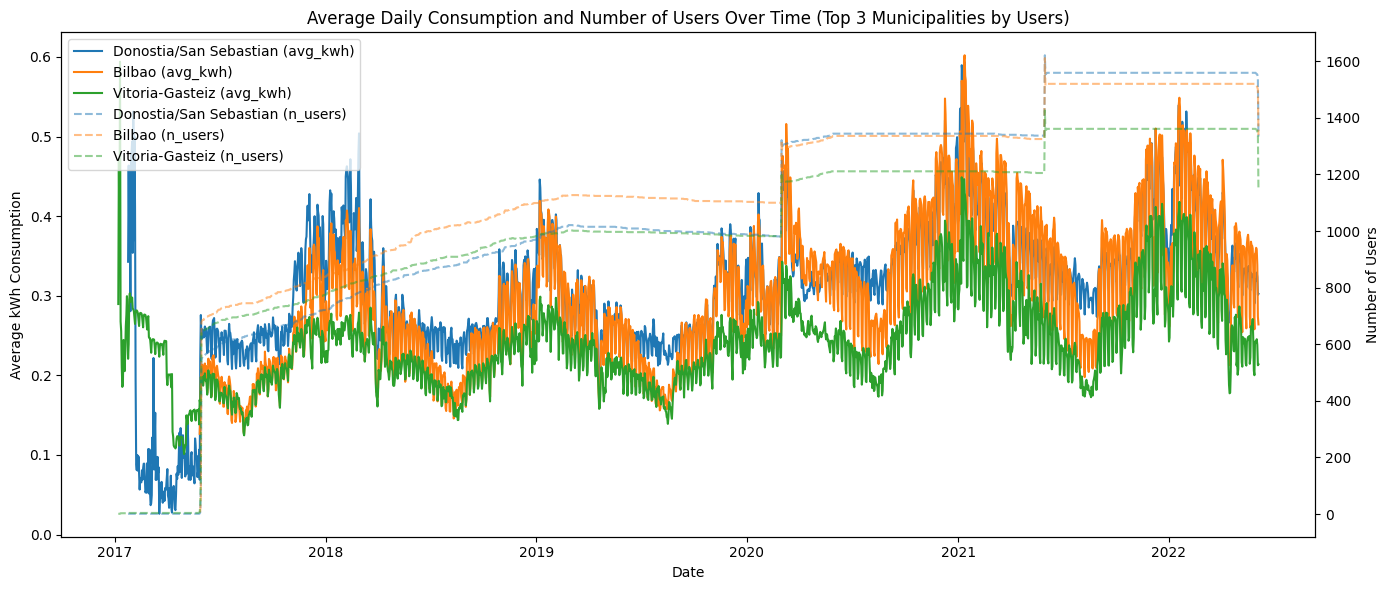

In [ ]:
plt.figure(figsize=(14, 6))
ax1 = plt.gca()
top3 = municipality_daily.groupby('municipality')['n_users'].max().sort_values(ascending=False).head(3).index.tolist()
for municipality in top3:
    subset = municipality_daily[municipality_daily['municipality'] == municipality]
    ax1.plot(subset['date'], subset['avg_kwh'], label=f"{municipality} (avg_kwh)")
    
ax1.set_xlabel('Date')
ax1.set_ylabel('Average kWh Consumption')
ax1.set_title('Average Daily Consumption and Number of Users Over Time (Top 3 Municipalities by Users)')

# Secondary y-axis for number of users
ax2 = ax1.twinx()
for municipality in top3:
    subset = municipality_daily[municipality_daily['municipality'] == municipality]
    ax2.plot(subset['date'], subset['n_users'], linestyle='--', alpha=0.5, label=f"{municipality} (n_users)")

ax2.set_ylabel('Number of Users')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

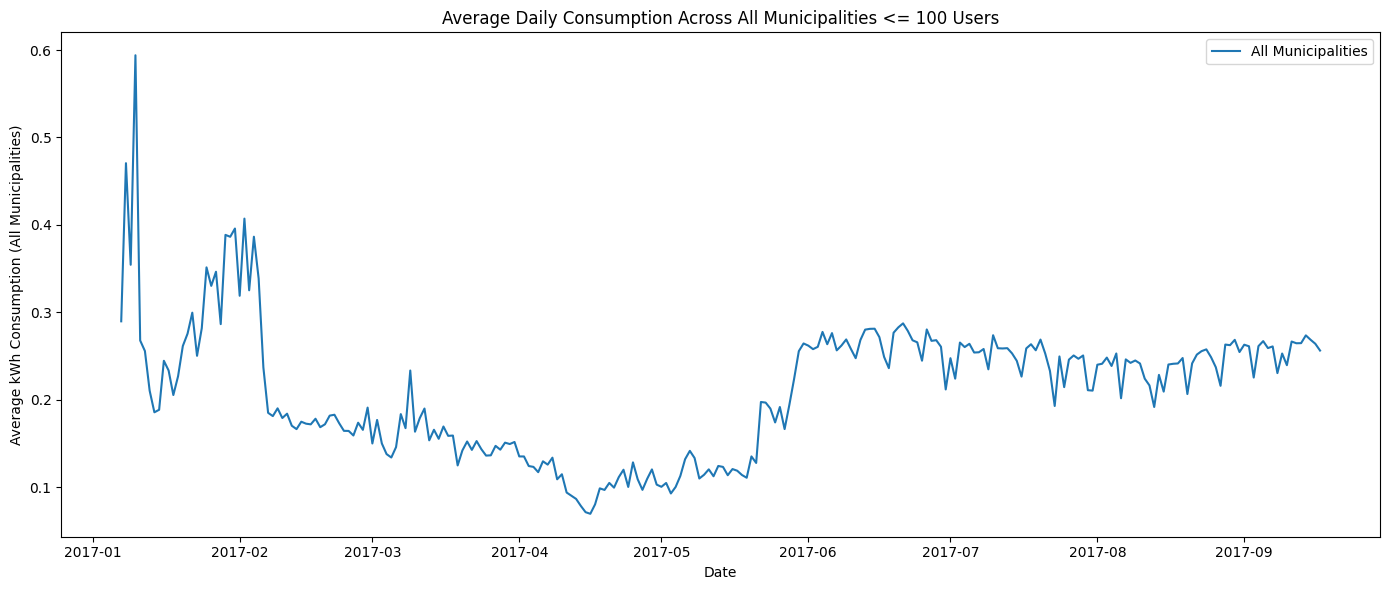

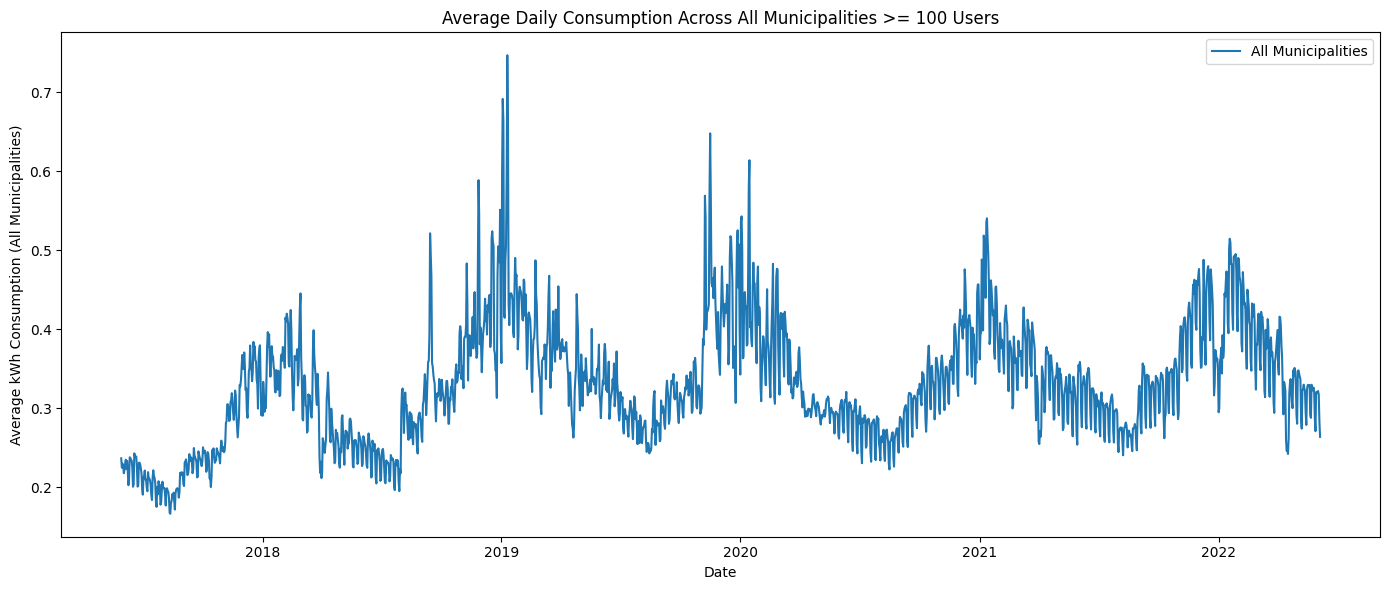

In [ ]:
filtered_municipality_daily = municipality_daily[municipality_daily['n_users'] <= MIN_USERS]
daily_avg_all_municipalities = filtered_municipality_daily.groupby('date')['avg_kwh'].mean().reset_index()
daily_avg_all_municipalities.rename(columns={'avg_kwh': 'avg_kwh_all_municipalities'}, inplace=True)


plt.figure(figsize=(14, 6))
plt.plot(
    daily_avg_all_municipalities['date'],
    daily_avg_all_municipalities['avg_kwh_all_municipalities'],
    label='All Municipalities'
)
plt.xlabel('Date')
plt.ylabel('Average kWh Consumption (All Municipalities)')
plt.title('Average Daily Consumption Across All Municipalities <= 100 Users')
plt.legend()
plt.tight_layout()
plt.show()
# Average daily consumption across all municipalities (filtering for municipalities with at least MIN_USERS)
filtered_municipality_daily = municipality_daily[municipality_daily['n_users'] >= MIN_USERS]
daily_avg_all_municipalities = filtered_municipality_daily.groupby('date')['avg_kwh'].mean().reset_index()
daily_avg_all_municipalities.rename(columns={'avg_kwh': 'avg_kwh_all_municipalities'}, inplace=True)


plt.figure(figsize=(14, 6))
plt.plot(
    daily_avg_all_municipalities['date'],
    daily_avg_all_municipalities['avg_kwh_all_municipalities'],
    label='All Municipalities'
)
plt.xlabel('Date')
plt.ylabel('Average kWh Consumption (All Municipalities)')
plt.title('Average Daily Consumption Across All Municipalities >= 100 Users')
plt.legend()
plt.tight_layout()
plt.show()

        date  avg_kwh_all_municipalities
0 2017-05-30                    0.236812
1 2017-05-31                    0.224982
2 2017-06-01                    0.229982
3 2017-06-02                    0.228530
4 2017-06-03                    0.217950


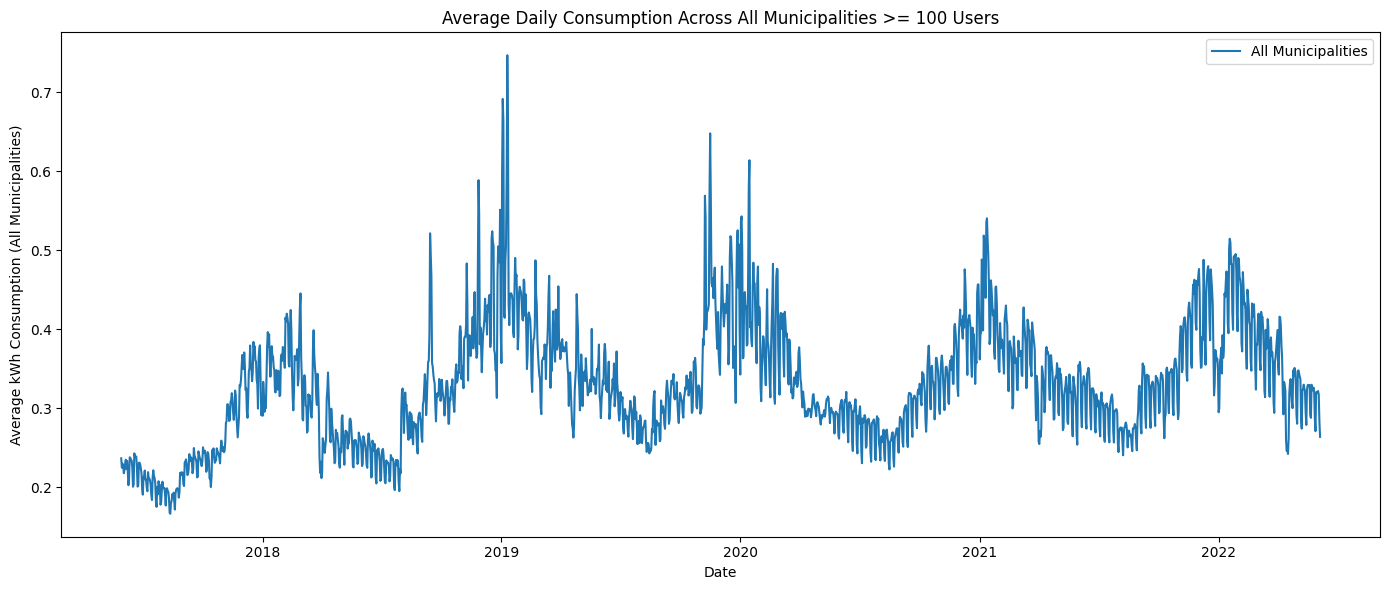

In [ ]:
# Average daily consumption across all municipalities (filtering for municipalities with at least MIN_USERS)
filtered_municipality_daily = municipality_daily[municipality_daily['n_users'] >= MIN_USERS]
daily_avg_all_municipalities = filtered_municipality_daily.groupby('date')['avg_kwh'].mean().reset_index()
daily_avg_all_municipalities.rename(columns={'avg_kwh': 'avg_kwh_all_municipalities'}, inplace=True)

print(daily_avg_all_municipalities.head())

plt.figure(figsize=(14, 6))
plt.plot(
    daily_avg_all_municipalities['date'],
    daily_avg_all_municipalities['avg_kwh_all_municipalities'],
    label='All Municipalities'
)
plt.xlabel('Date')
plt.ylabel('Average kWh Consumption (All Municipalities)')
plt.title('Average Daily Consumption Across All Municipalities >= 100 Users')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the number of unique days per municipality
days_per_municipality = municipality_daily.groupby('municipality')['date'].unique()

# Count the number of unique days per municipality
num_days_per_municipality = days_per_municipality.apply(len)

# Convert days to years (approximate, using 365 days per year)
years_per_municipality = num_days_per_municipality / 365

# Count municipalities with more than 3 years and more than 4 years
more_than_3_years = (years_per_municipality > 3).sum()
more_than_4_years = (years_per_municipality > 4).sum()
more_than_5_years = (years_per_municipality > 5).sum()

print(f"Municipalities with more than 3 years of data: {more_than_3_years}")
print(f"Municipalities with more than 4 years of data: {more_than_4_years}")
print(f"Municipalities with more than 5 years of data: {more_than_5_years}")



Municipalities with more than 3 years of data: 6
Municipalities with more than 4 years of data: 6
Municipalities with more than 5 years of data: 6


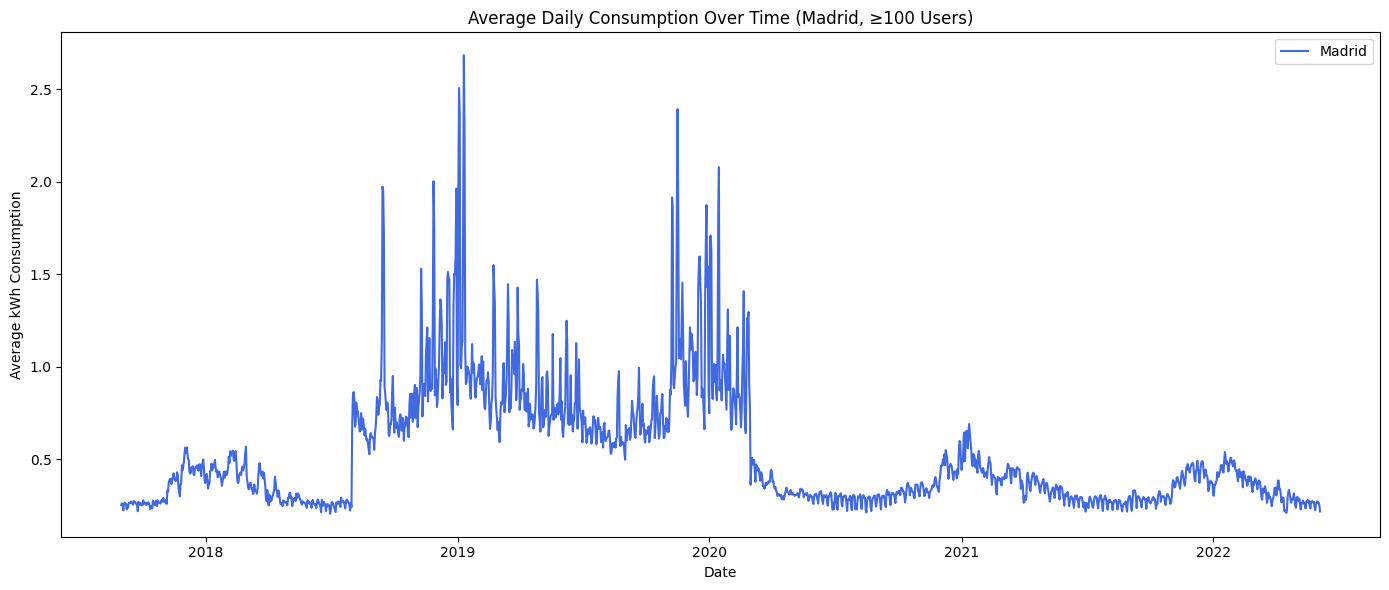

In [ ]:
madrid_daily = filtered_municipality_daily[filtered_municipality_daily['municipality'] == 'Irun']

plt.figure(figsize=(14, 6))
plt.plot(madrid_daily['date'], madrid_daily['avg_kwh'], label='Madrid', color='royalblue')

plt.xlabel('Date')
plt.ylabel('Average kWh Consumption')
plt.title('Average Daily Consumption Over Time (Madrid, ≥100 Users)')
plt.legend()
plt.tight_layout()
plt.show()

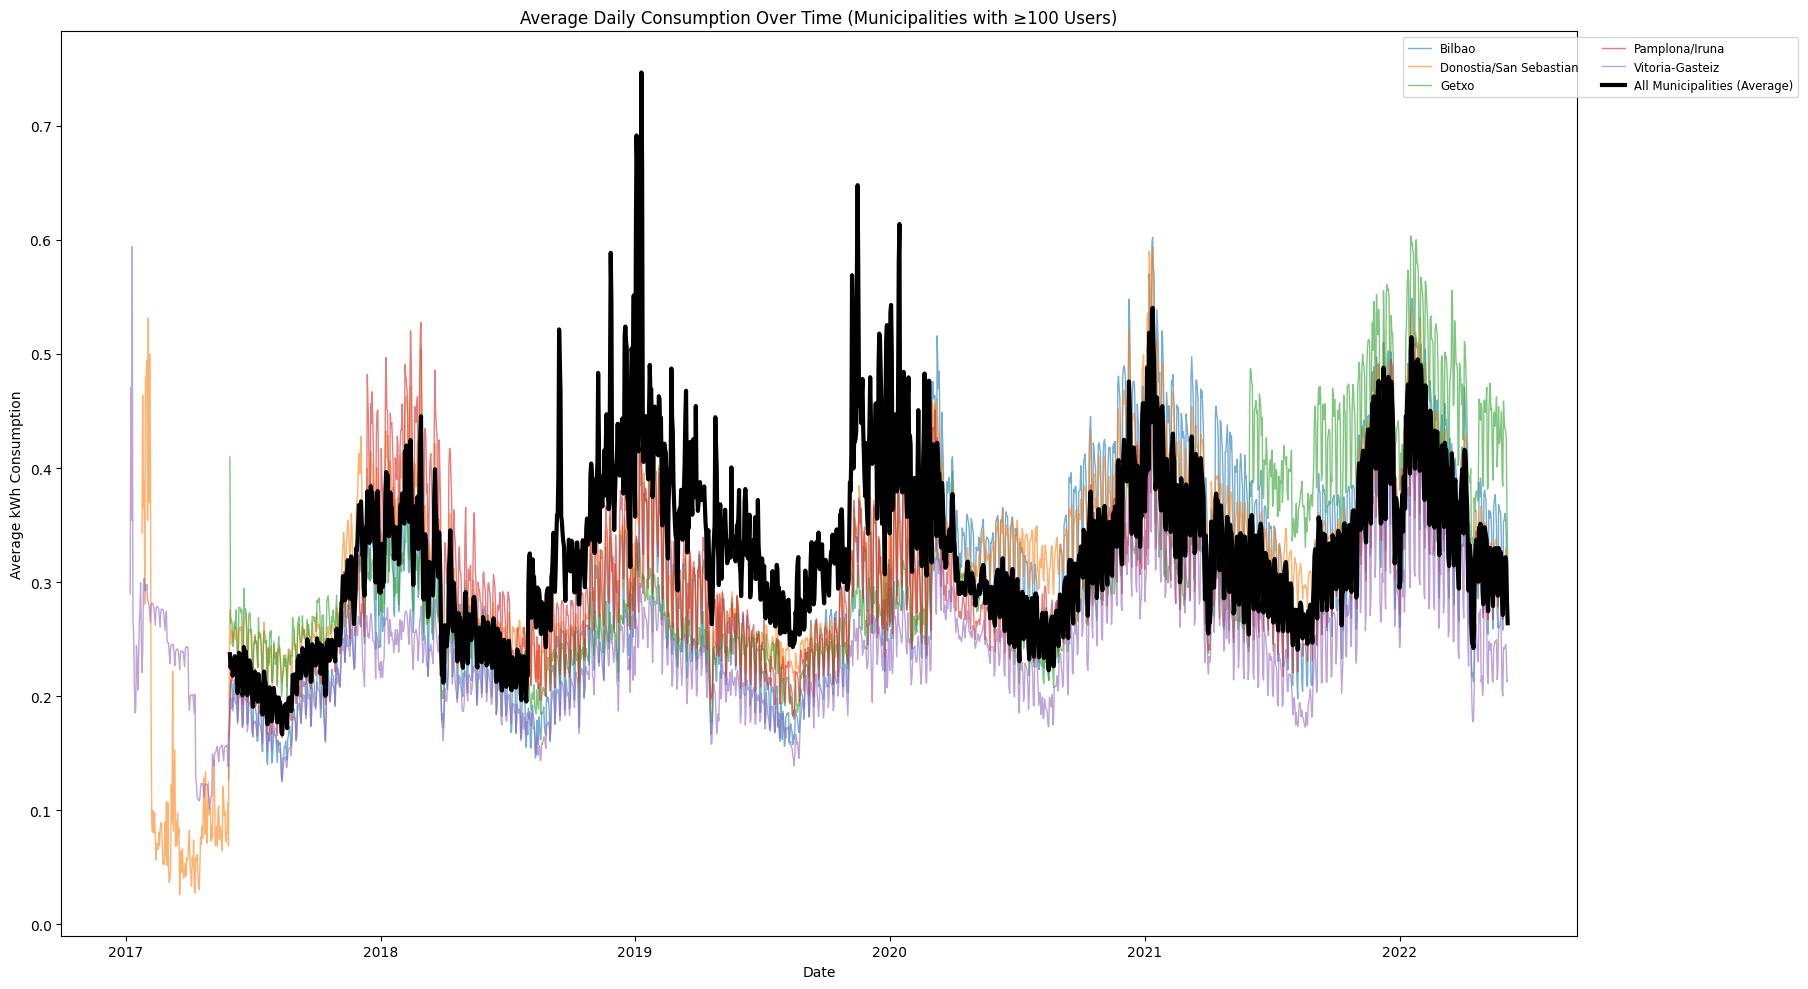

In [ ]:
# Filter municipalities with at least 100 users at any point, excluding 'Irun'
municipalities_100plus = municipality_daily.groupby('municipality')['n_users'].max()
municipalities_100plus = municipalities_100plus[municipalities_100plus >= MIN_USERS].index
municipalities_100plus = municipalities_100plus.drop('Irun') if 'Irun' in municipalities_100plus else municipalities_100plus
filtered_municipality_daily = municipality_daily[municipality_daily['municipality'].isin(municipalities_100plus)]

plt.figure(figsize=(18, 10))
for municipality in filtered_municipality_daily['municipality'].unique():
    subset = filtered_municipality_daily[filtered_municipality_daily['municipality'] == municipality]
    plt.plot(subset['date'], subset['avg_kwh'], alpha=0.6, linewidth=1, label=municipality)

# Plot the average across all municipalities
plt.plot(
    daily_avg_all_municipalities['date'],
    daily_avg_all_municipalities['avg_kwh_all_municipalities'],
    color='black', linewidth=3, label='All Municipalities (Average)'
)

plt.xlabel('Date')
plt.ylabel('Average kWh Consumption')
plt.title('Average Daily Consumption Over Time (Municipalities with ≥100 Users)')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

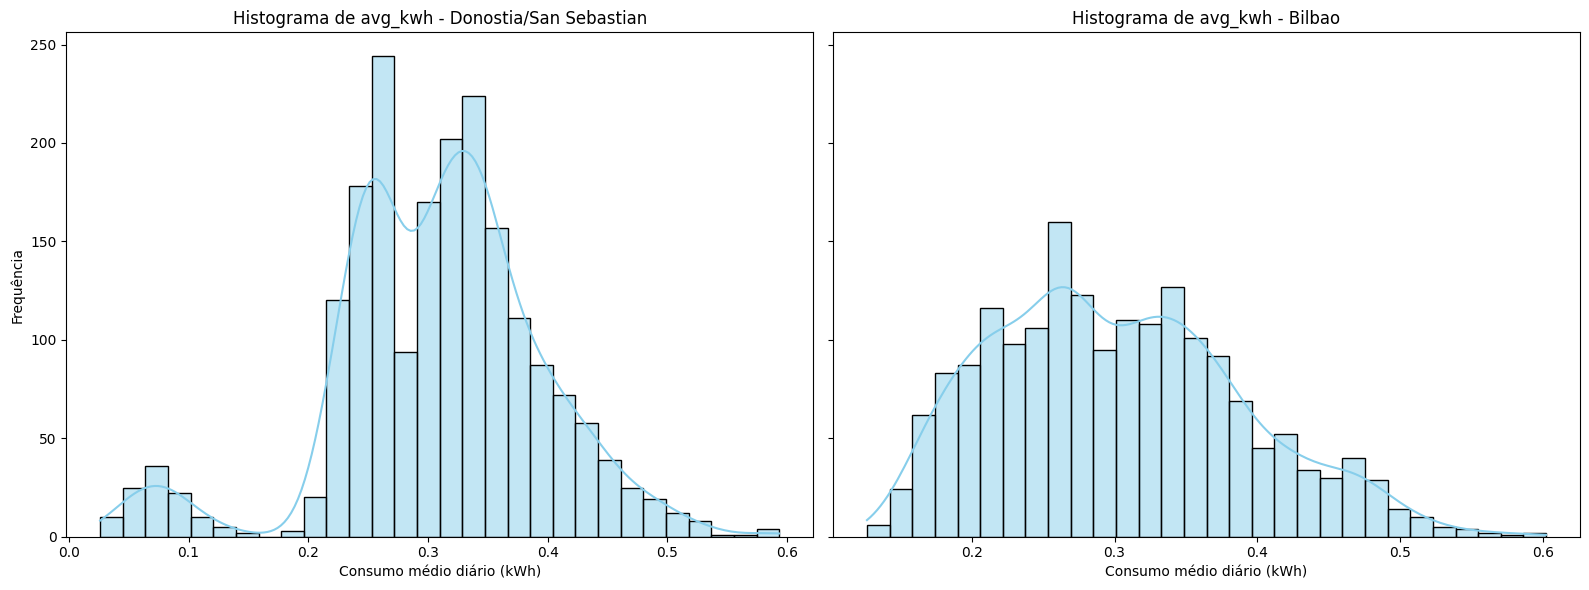

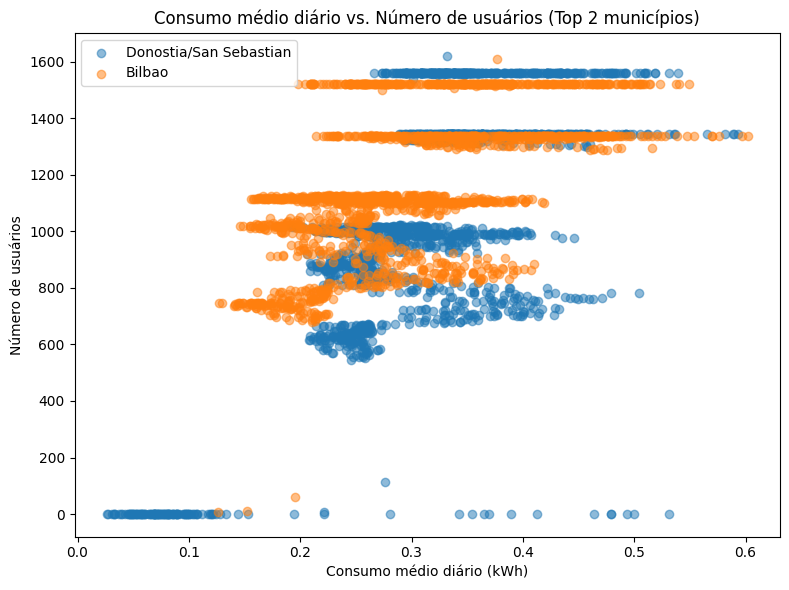

In [ ]:
# Encontrar os 2 municípios com mais usuários únicos
top2 = municipality_daily.groupby('municipality')['n_users'].max().sort_values(ascending=False).head(2).index.tolist()

# Selecionar dados apenas desses municípios
top2_df = municipality_daily[municipality_daily['municipality'].isin(top2)]

# Distribuição univariada: histograma do consumo médio diário para cada município
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for i, muni in enumerate(top2):
    sns.histplot(
        top2_df[top2_df['municipality'] == muni]['avg_kwh'],
        bins=30, kde=True, ax=axes[i], color='skyblue'
    )
    axes[i].set_title(f'Histograma de avg_kwh - {muni}')
    axes[i].set_xlabel('Consumo médio diário (kWh)')
    axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# Distribuição bivariada: scatterplot entre consumo médio e número de usuários
plt.figure(figsize=(8, 6))
for muni in top2:
    subset = top2_df[top2_df['municipality'] == muni]
    plt.scatter(subset['avg_kwh'], subset['n_users'], alpha=0.5, label=muni)
plt.xlabel('Consumo médio diário (kWh)')
plt.ylabel('Número de usuários')
plt.title('Consumo médio diário vs. Número de usuários (Top 2 municípios)')
plt.legend()
plt.tight_layout()
plt.show()

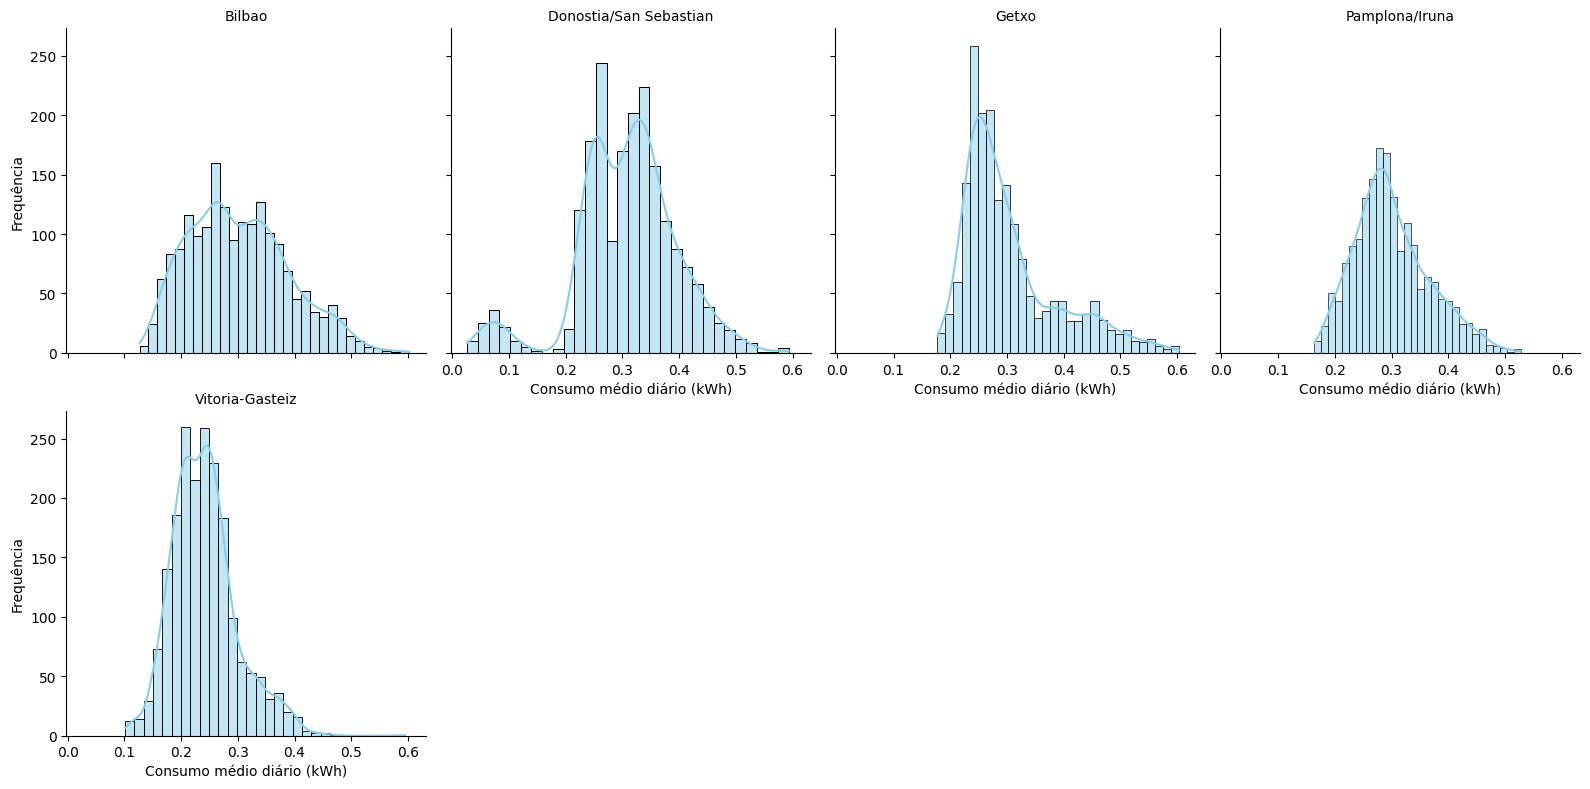

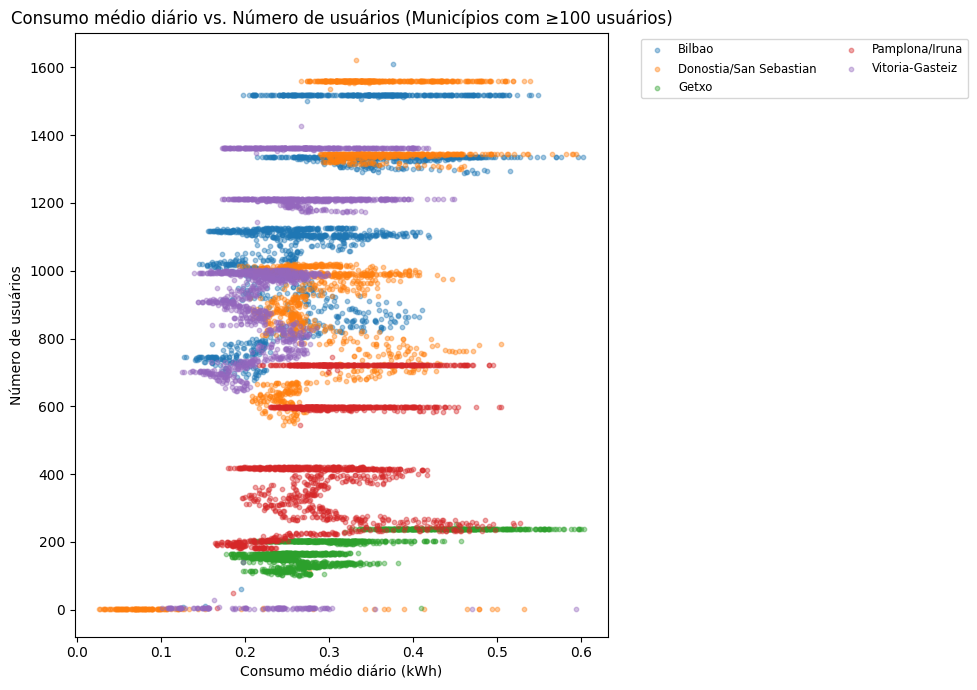

In [ ]:
# Histograms for all municipalities
# Filter for municipalities with at least 100 users at any point
municipalities_100plus = municipality_daily.groupby('municipality')['n_users'].max()
municipalities_100plus = municipalities_100plus[municipalities_100plus >= MIN_USERS].index
municipalities_100plus = municipalities_100plus.drop('Irun') if 'Irun' in municipalities_100plus else municipalities_100plus
filtered_municipality_daily = municipality_daily[municipality_daily['municipality'].isin(municipalities_100plus)]


g = sns.FacetGrid(filtered_municipality_daily, col="municipality", col_wrap=4, sharey=True, height=4)
g.map(sns.histplot, "avg_kwh", bins=30, color='skyblue', kde=True)
g.set_axis_labels("Consumo médio diário (kWh)", "Frequência")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

# Scatterplot: avg_kwh vs n_users for filtered municipalities
plt.figure(figsize=(10, 7))
for muni in filtered_municipality_daily['municipality'].unique():
    subset = filtered_municipality_daily[filtered_municipality_daily['municipality'] == muni]
    plt.scatter(subset['avg_kwh'], subset['n_users'], alpha=0.4, label=muni, s=10)
plt.xlabel('Consumo médio diário (kWh)')
plt.ylabel('Número de usuários')
plt.title('Consumo médio diário vs. Número de usuários (Municípios com ≥100 usuários)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()


3 municipios com o consumo médio diário mais alto, mais baixo e mais igual à média 
olhar para cada um deles e verificar a quantidade de users para cada municipio 



In [ ]:
municipality_diffs = {}

for muni in filtered_municipality_daily['municipality'].unique():
    muni_series = filtered_municipality_daily[
        filtered_municipality_daily['municipality'] == muni
    ][['date', 'avg_kwh']]

    merged = pd.merge(
        muni_series,
        daily_avg_all_municipalities,
        on='date',
        how='inner'
    )

    # Signed difference
    mean_diff = (
        merged['avg_kwh'] - merged['avg_kwh_all_municipalities']
    ).mean()

    municipality_diffs[muni] = mean_diff

municipality_diffs = pd.Series(municipality_diffs)

# Most above average
most_above = municipality_diffs.idxmax()

# Most below average
most_below = municipality_diffs.idxmin()

print(f"Most above average: {most_above} ({municipality_diffs[most_above]:.4f})")
print(f"Most below average: {most_below} ({municipality_diffs[most_below]:.4f})")

Most above average: Donostia/San Sebastian (-0.0083)
Most below average: Vitoria-Gasteiz (-0.0867)


In [ ]:
municipality_diffs = {}

for muni in filtered_municipality_daily['municipality'].unique():
    muni_series = filtered_municipality_daily[
        filtered_municipality_daily['municipality'] == muni
    ][['date', 'avg_kwh']]

    merged = pd.merge(
        muni_series,
        daily_avg_all_municipalities,
        on='date',
        how='inner'
    )

    diff = merged['avg_kwh'] - merged['avg_kwh_all_municipalities']

    municipality_diffs[muni] = {
        'mean_diff': diff.mean(),           # Signed: above (+) or below (-)
        'abs_mean_diff': diff.abs().mean()  # Unsigned: how far from average
    }

municipality_diffs = pd.DataFrame(municipality_diffs).T

most_above   = municipality_diffs['mean_diff'].idxmax()
most_below   = municipality_diffs['mean_diff'].idxmin()
most_similar = municipality_diffs['abs_mean_diff'].idxmin()  # Closest to 0

print(f"Most above average:  {most_above}   ({municipality_diffs.loc[most_above,   'mean_diff']:+.4f} kWh/day)")
print(f"Most below average:  {most_below}   ({municipality_diffs.loc[most_below,   'mean_diff']:+.4f} kWh/day)")
print(f"Most similar:        {most_similar} ({municipality_diffs.loc[most_similar, 'abs_mean_diff']:.4f} kWh/day avg deviation)")

Most above average:  Donostia/San Sebastian   (-0.0083 kWh/day)
Most below average:  Vitoria-Gasteiz   (-0.0867 kWh/day)
Most similar:        Pamplona/Iruna (0.0428 kWh/day avg deviation)


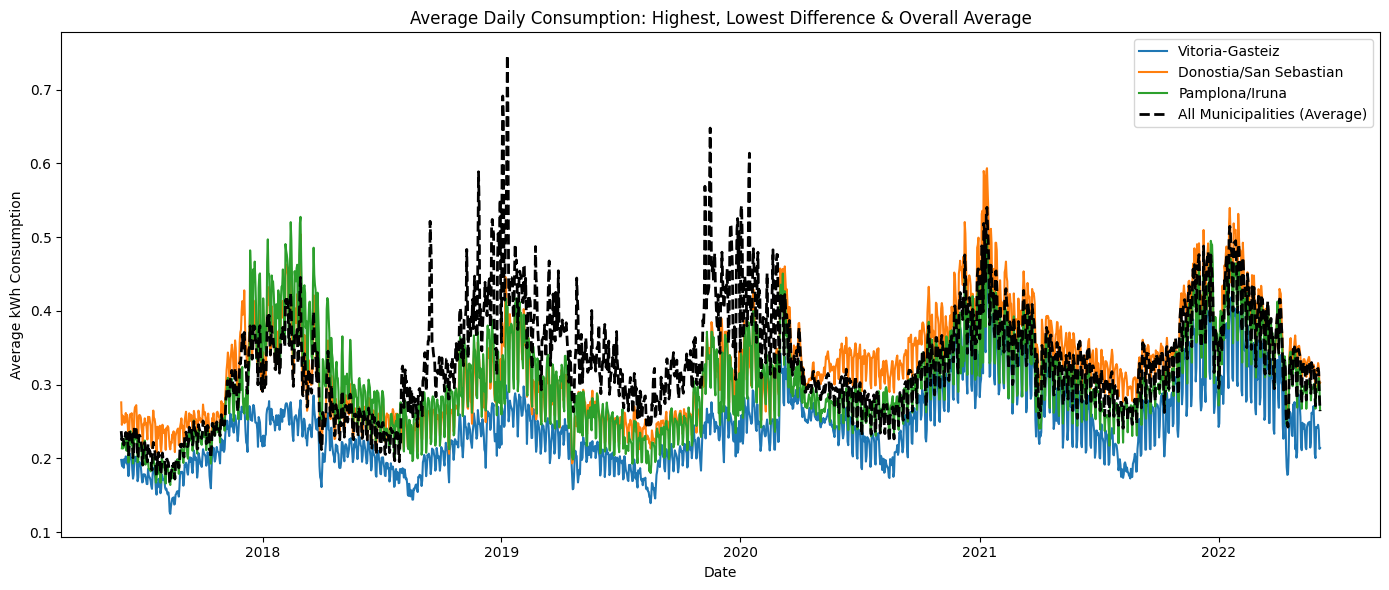

In [ ]:
# Select the municipalities of interest
munis_to_plot = ['Vitoria-Gasteiz', 'Donostia/San Sebastian', 'Pamplona/Iruna']

plt.figure(figsize=(14, 6))
for muni in munis_to_plot:
    subset = filtered_municipality_daily[
        (filtered_municipality_daily['municipality'] == muni) &
        (filtered_municipality_daily['n_users'] > 100)
    ]
    plt.plot(subset['date'], subset['avg_kwh'], label=muni)

# Plot the overall average
plt.plot(
    daily_avg_all_municipalities['date'],
    daily_avg_all_municipalities['avg_kwh_all_municipalities'],
    color='black', linewidth=2, linestyle='--', label='All Municipalities (Average)'
)

plt.xlabel('Date')
plt.ylabel('Average kWh Consumption')
plt.title('Average Daily Consumption: Highest, Lowest Difference & Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

Average number of users for each municipality:
municipality
Bilbao                    1180.402725
Donostia/San Sebastian    1054.692700
Getxo                      180.332242
Pamplona/Iruna             476.438386
Vitoria-Gasteiz            989.720142
Name: n_users, dtype: float64


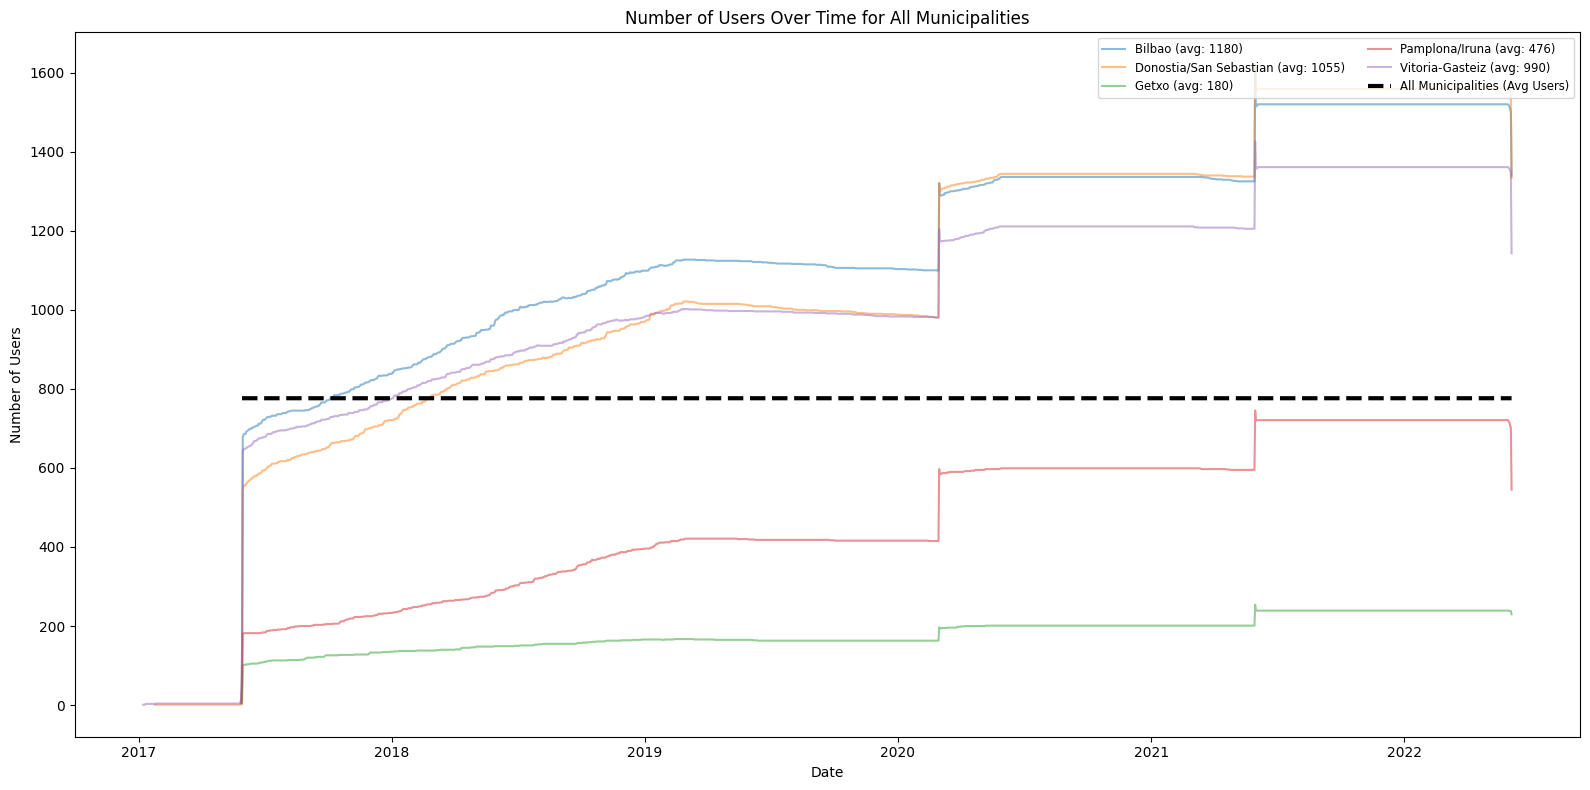

In [ ]:
# Calculate average number of users for each municipality in munis_to_plot + others
all_munis = filtered_municipality_daily['municipality'].unique().tolist()
avg_users_all = filtered_municipality_daily.groupby('municipality')['n_users'].mean()

print("Average number of users for each municipality:")
print(avg_users_all)

plt.figure(figsize=(16, 8))
for muni in all_munis:
    subset = filtered_municipality_daily[filtered_municipality_daily['municipality'] == muni]
    plt.plot(subset['date'], subset['n_users'], alpha=0.5, label=f"{muni} (avg: {avg_users_all[muni]:.0f})")

# Plot the overall average (all municipalities combined)
plt.plot(
    daily_avg_all_municipalities['date'],
    [avg_users_all.mean()] * len(daily_avg_all_municipalities),
    color='black', linewidth=3, linestyle='--', label='All Municipalities (Avg Users)'
)

plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.title('Number of Users Over Time for All Municipalities')
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

## Baseline Forecasting

We'll evaluate four baselines:

| Model | Description |
|---|---|
| **Naive** | Next value = last observed value |
| **Seasonal Naive** | Next value = same weekday/week last year |
| **Rolling Mean** | Next value = rolling 7-day average |
| **Historical Mean** | Next value = train-set global mean |

We use a **80/20 train-test split** per municipality and measure:
- **MAE** – Mean Absolute Error
- **RMSE** – Root Mean Squared Error
- **MAPE** – Mean Absolute Percentage Error

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── Helper: evaluation metrics ──────────────────────────────────────────────
def evaluate(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100
    return {'Model': model_name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'MAPE(%)': round(mape,2)}

# ── Seasonal Naive helper ────────────────────────────────────────────────────
def seasonal_naive(train, test, period=365):
    preds = []
    for date in test.index:
        lag_date = date - pd.DateOffset(days=period)
        for d in range(8):
            candidate = lag_date - pd.DateOffset(days=d)
            if candidate in train.index and not np.isnan(train[candidate]):
                preds.append(train[candidate])
                break
        else:
            preds.append(train.mean())
    return pd.Series(preds, index=test.index)

# ── The 3 chosen municipalities ──────────────────────────────────────────────
munis_to_plot = ['Vitoria-Gasteiz', 'Donostia/San Sebastian', 'Pamplona/Iruna']

baseline_results_per_muni = {}
ts_per_muni = {}
split_per_muni = {}

for FORECAST_MUNI in munis_to_plot:
    print(f"\n{'='*60}")
    print(f"Forecasting municipality: {FORECAST_MUNI}")
    print(f"{'='*60}")

    ts = (
        filtered_municipality_daily[
            (filtered_municipality_daily['municipality'] == FORECAST_MUNI) &
            (filtered_municipality_daily['n_users'] > 100)
        ]
        [['date', 'avg_kwh']]
        .sort_values('date')
        .set_index('date')
        .asfreq('D')
        ['avg_kwh']
        .interpolate('linear')
    )

    split_idx = int(len(ts) * 0.80)
    train, test = ts.iloc[:split_idx], ts.iloc[split_idx:]
    print(f'Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} days)')
    print(f'Test : {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)}  days)')

    ts_per_muni[FORECAST_MUNI] = ts
    split_per_muni[FORECAST_MUNI] = (train, test)

    # ── Baselines ─────────────────────────────────────────────────────────────
    naive_pred     = pd.Series(train.iloc[-1], index=test.index)
    seasonal_pred  = seasonal_naive(train, test, period=365)
    rolling_val    = train.rolling(7).mean().iloc[-1]
    rolling_pred   = pd.Series(rolling_val, index=test.index)
    hist_mean_pred = pd.Series(train.mean(), index=test.index)

    results = pd.DataFrame([
        evaluate(test, naive_pred,       'Naive'),
        evaluate(test, seasonal_pred,    'Seasonal Naive (365d)'),
        evaluate(test, rolling_pred,     'Rolling Mean (7d)'),
        evaluate(test, hist_mean_pred,   'Historical Mean'),
    ]).set_index('Model').sort_values('RMSE')

    baseline_results_per_muni[FORECAST_MUNI] = {
        'results': results,
        'train': train, 'test': test,
        'naive_pred': naive_pred,
        'seasonal_pred': seasonal_pred,
        'rolling_pred': rolling_pred,
        'hist_mean_pred': hist_mean_pred,
    }

    print(f'\nBaseline results for {FORECAST_MUNI}:')
    display(results)
    best_model = results['RMSE'].idxmin()
    print(f"Best baseline by RMSE: {best_model}")



Forecasting municipality: Vitoria-Gasteiz
Train: 2017-05-30 → 2021-06-03  (1466 days)
Test : 2021-06-04  → 2022-06-05   (367  days)

Baseline results for Vitoria-Gasteiz:


,MAE,RMSE,MAPE(%)
Model,,,
Seasonal Naive (365d),0.0308,0.0417,11.29
Naive,0.0537,0.0634,21.31
Rolling Mean (7d),0.0507,0.0636,18.14
Historical Mean,0.0572,0.0738,18.92


Best baseline by RMSE: Seasonal Naive (365d)

Forecasting municipality: Donostia/San Sebastian
Train: 2017-05-30 → 2021-06-03  (1466 days)
Test : 2021-06-04  → 2022-06-05   (367  days)

Baseline results for Donostia/San Sebastian:


,MAE,RMSE,MAPE(%)
Model,,,
Seasonal Naive (365d),0.0358,0.0480,9.76
Naive,0.0481,0.0596,12.85
Rolling Mean (7d),0.0483,0.0676,11.97
Historical Mean,0.0584,0.0799,14.26


Best baseline by RMSE: Seasonal Naive (365d)

Forecasting municipality: Pamplona/Iruna
Train: 2017-05-31 → 2021-06-03  (1465 days)
Test : 2021-06-04  → 2022-06-05   (367  days)

Baseline results for Pamplona/Iruna:


,MAE,RMSE,MAPE(%)
Model,,,
Seasonal Naive (365d),0.0297,0.0426,8.54
Naive,0.0499,0.0618,14.64
Historical Mean,0.0525,0.0707,14.40
Rolling Mean (7d),0.0542,0.0730,14.77


Best baseline by RMSE: Seasonal Naive (365d)


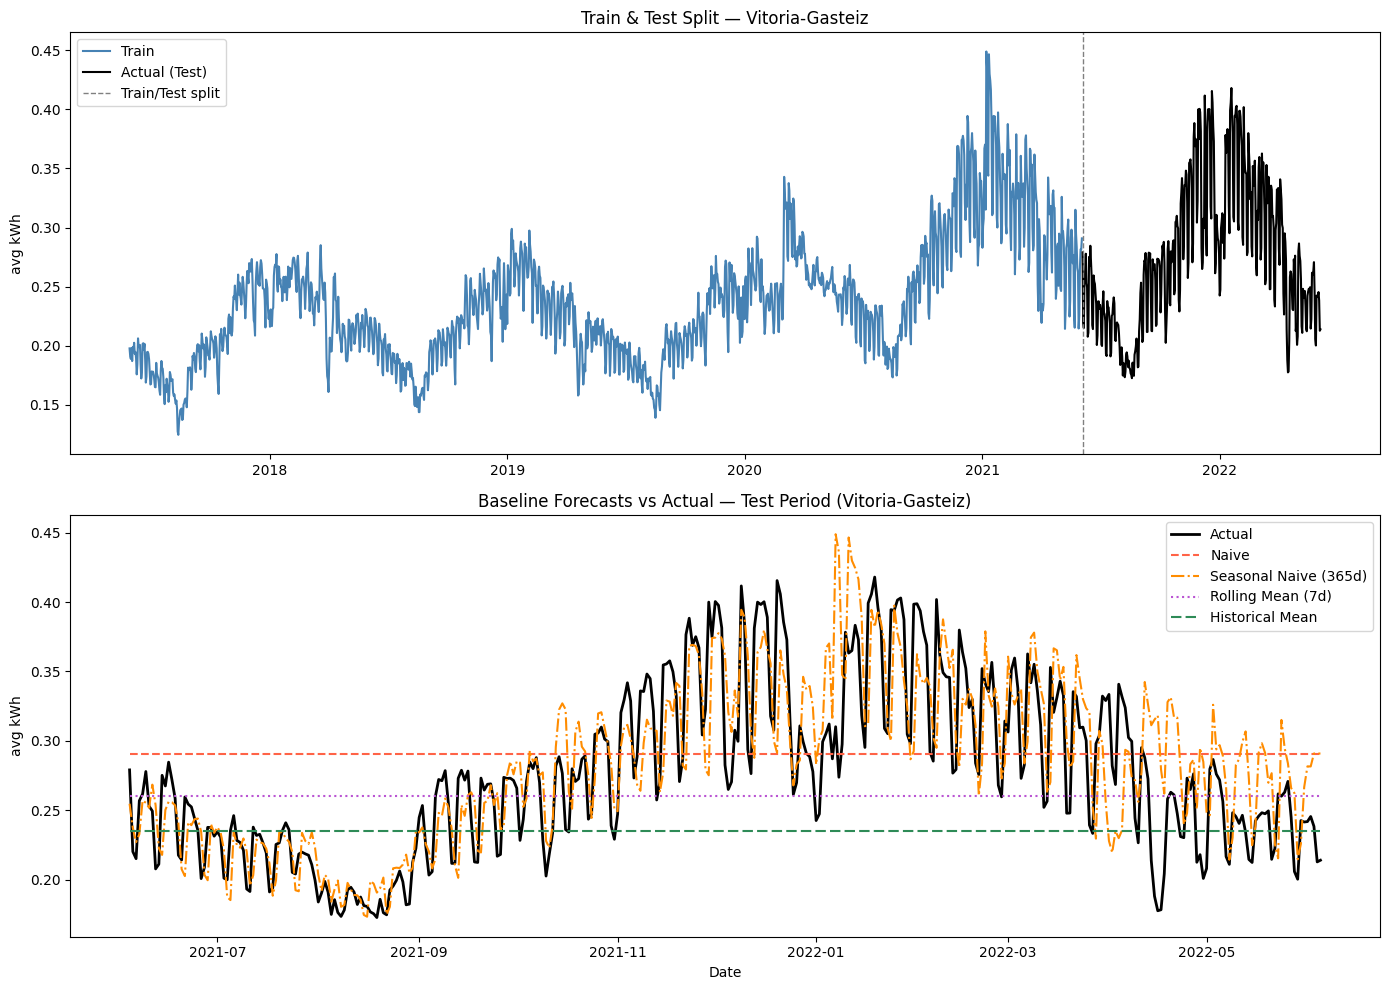

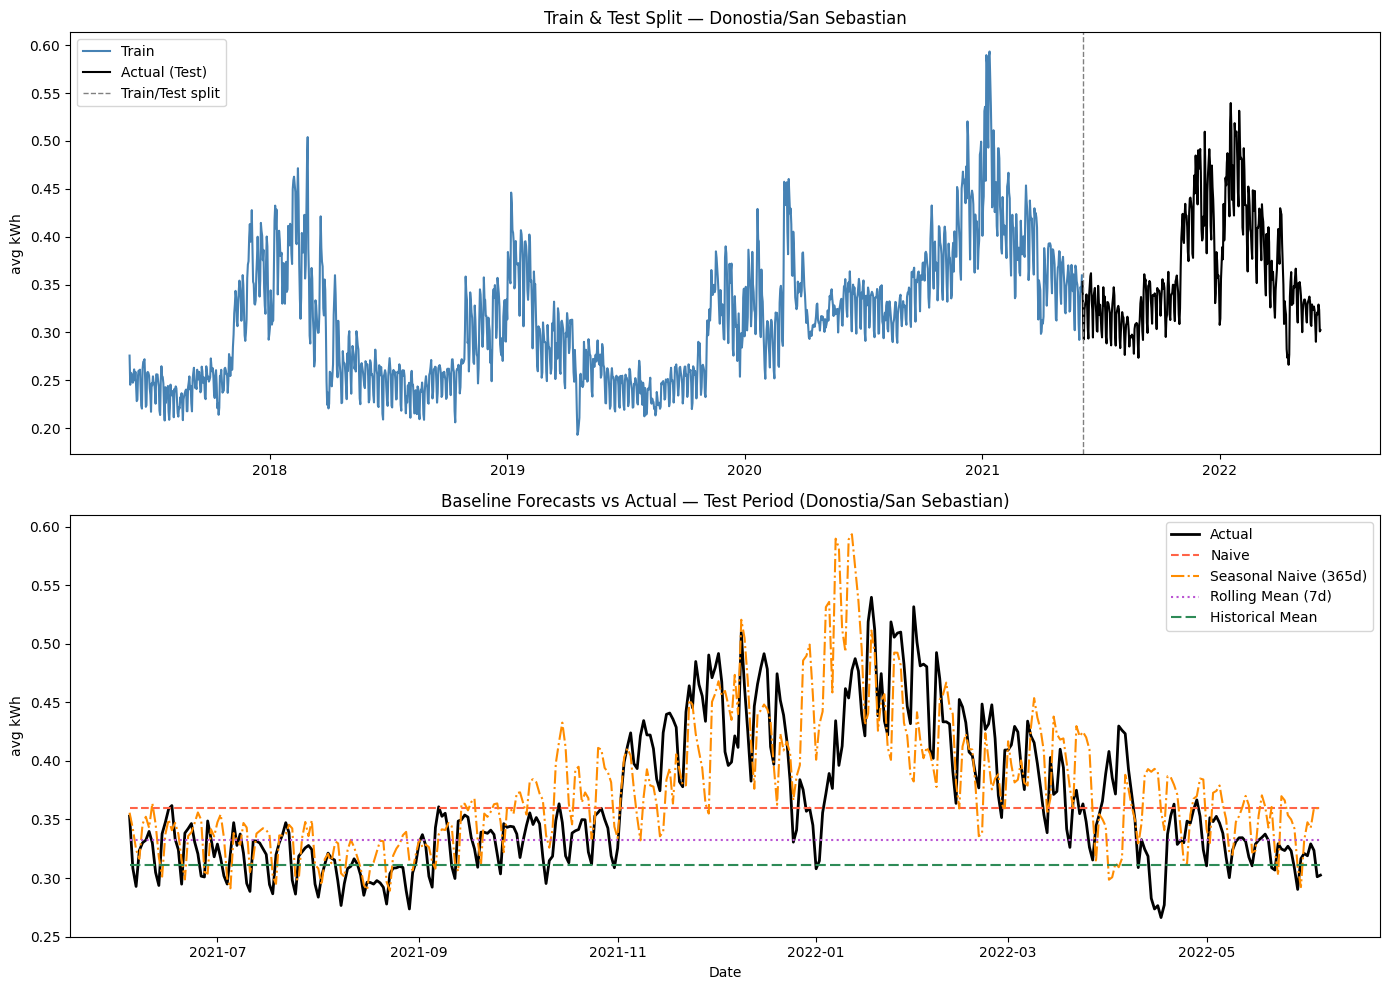

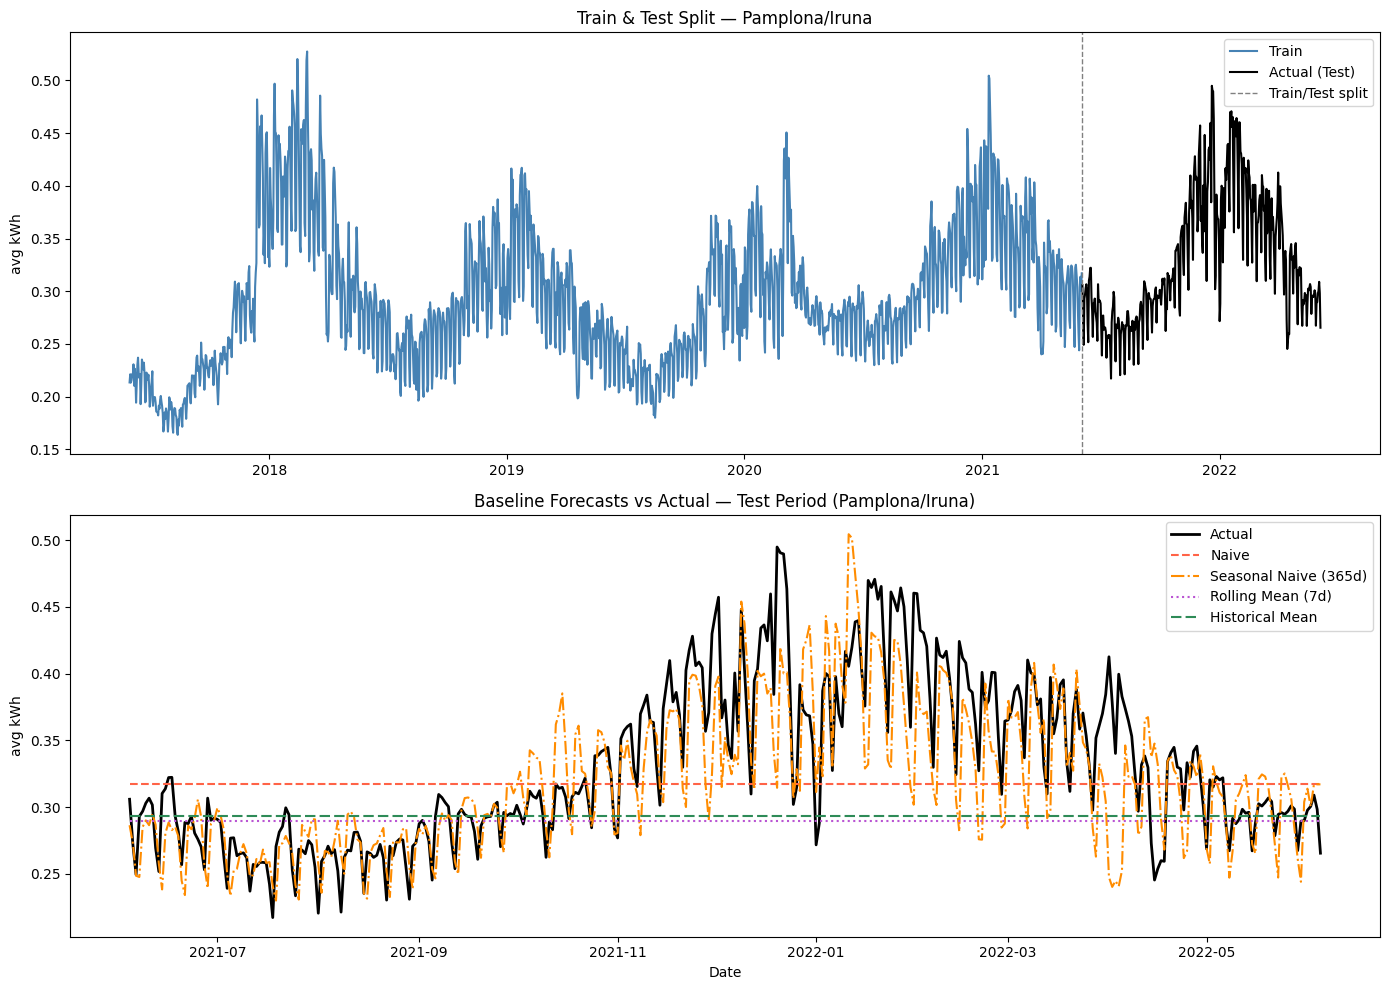

In [ ]:
# ── Visual comparison of baselines vs actuals — all 3 municipalities ────────
for FORECAST_MUNI in munis_to_plot:
    d = baseline_results_per_muni[FORECAST_MUNI]
    train, test = d['train'], d['test']
    results = d['results']

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Top: full series with train/test split
    ax = axes[0]
    ax.plot(train.index, train.values, color='steelblue', label='Train')
    ax.plot(test.index,  test.values,  color='black',     label='Actual (Test)', linewidth=1.5)
    ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=1, label='Train/Test split')
    ax.set_title(f'Train & Test Split — {FORECAST_MUNI}')
    ax.set_ylabel('avg kWh')
    ax.legend()

    # Bottom: zoom into test period
    ax2 = axes[1]
    ax2.plot(test.index, test.values,                color='black',        label='Actual',                  linewidth=2)
    ax2.plot(test.index, d['naive_pred'].values,     color='tomato',       label='Naive',                   linewidth=1.5, linestyle='--')
    ax2.plot(test.index, d['seasonal_pred'].values,  color='darkorange',   label='Seasonal Naive (365d)',   linewidth=1.5, linestyle='-.')
    ax2.plot(test.index, d['rolling_pred'].values,   color='mediumorchid', label='Rolling Mean (7d)',       linewidth=1.5, linestyle=':')
    ax2.plot(test.index, d['hist_mean_pred'].values, color='seagreen',     label='Historical Mean',         linewidth=1.5, linestyle=(0,(5,2)))
    ax2.set_title(f'Baseline Forecasts vs Actual — Test Period ({FORECAST_MUNI})')
    ax2.set_ylabel('avg kWh')
    ax2.set_xlabel('Date')
    ax2.legend()

    plt.tight_layout()
    plt.show()


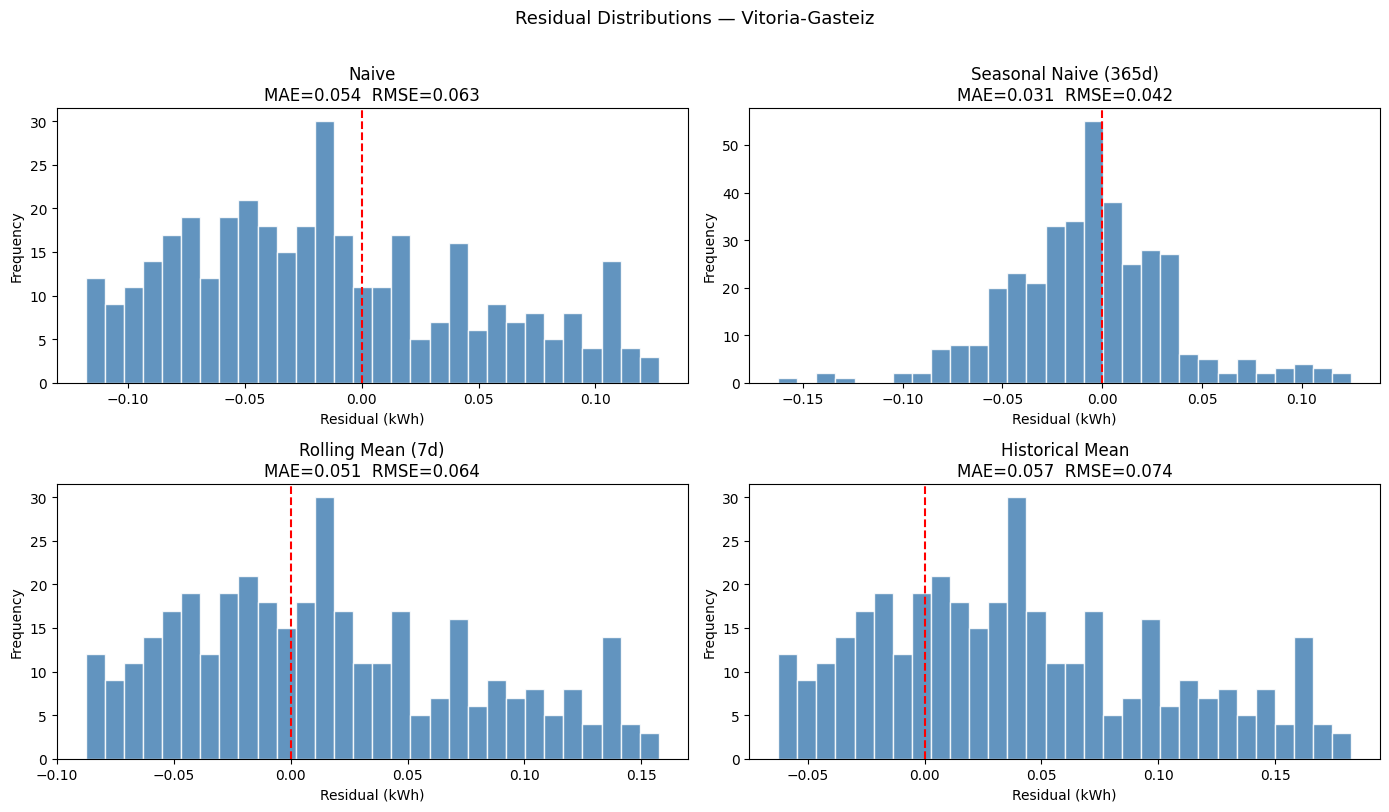

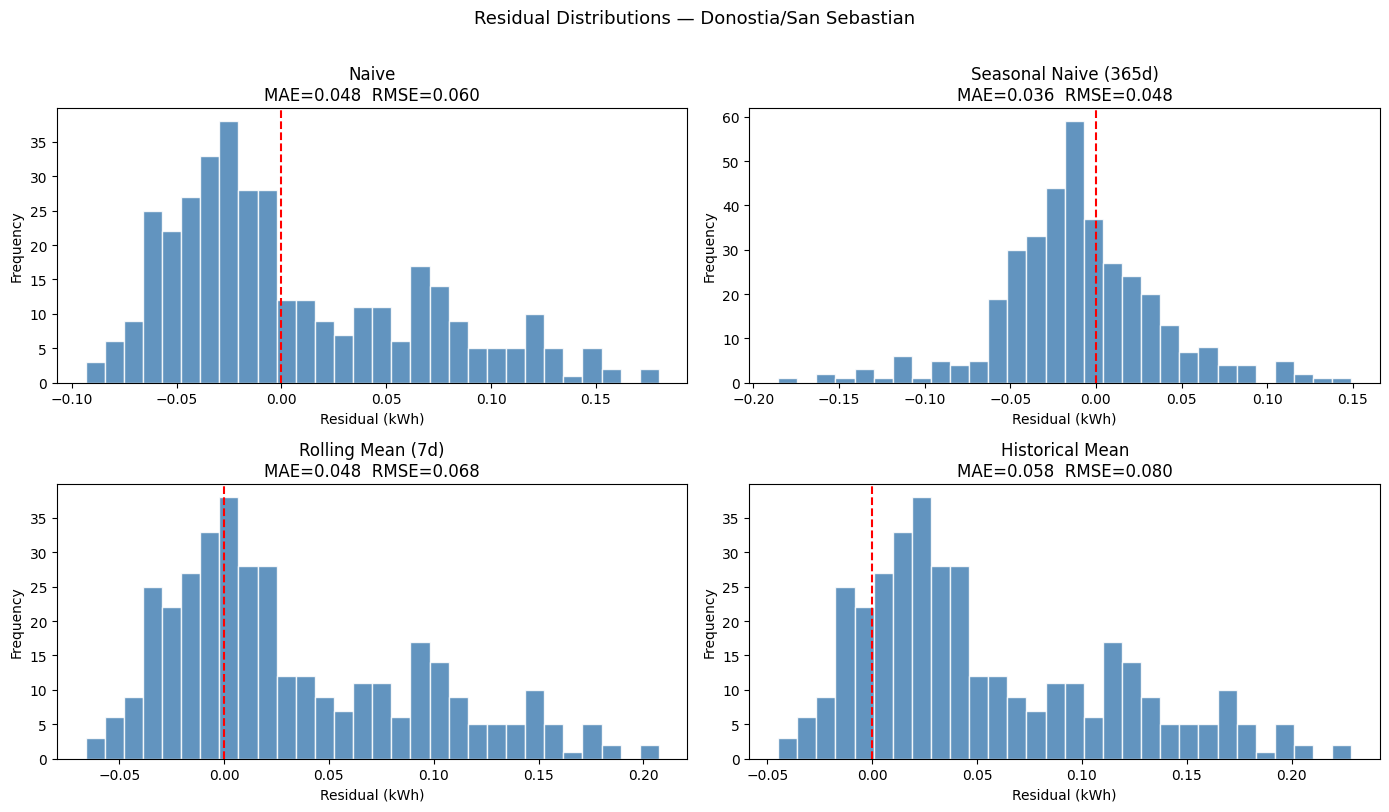

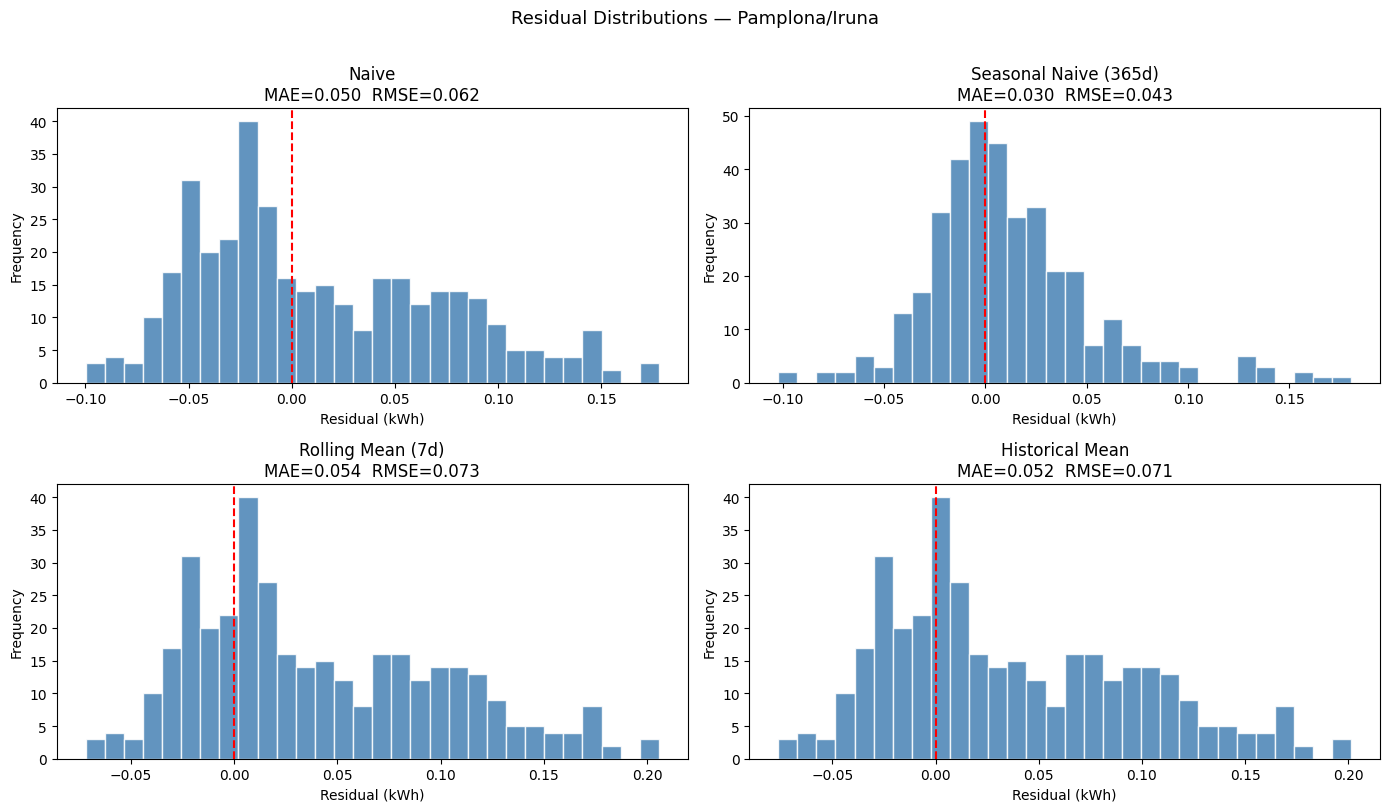

In [ ]:
# ── Residual distributions — all 3 municipalities ───────────────────────────
for FORECAST_MUNI in munis_to_plot:
    d = baseline_results_per_muni[FORECAST_MUNI]
    test, results = d['test'], d['results']

    forecasts = {
        'Naive':                  d['naive_pred'],
        'Seasonal Naive (365d)':  d['seasonal_pred'],
        'Rolling Mean (7d)':      d['rolling_pred'],
        'Historical Mean':        d['hist_mean_pred'],
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()

    for ax, (name, pred) in zip(axes, forecasts.items()):
        residuals = test - pred
        ax.hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
        ax.axvline(0, color='red', linestyle='--')
        ax.set_title(f'{name}\nMAE={results.loc[name,"MAE"]:.3f}  RMSE={results.loc[name,"RMSE"]:.3f}')
        ax.set_xlabel('Residual (kWh)')
        ax.set_ylabel('Frequency')

    plt.suptitle(f'Residual Distributions — {FORECAST_MUNI}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


RMSE per model and municipality:


Municipality,Donostia/San Sebastian,Pamplona/Iruna,Vitoria-Gasteiz
Model,,,
Historical Mean,0.0799,0.0707,0.0738
Naive,0.0596,0.0618,0.0634
Rolling Mean (7d),0.0676,0.0730,0.0636
Seasonal Naive (365d),0.0480,0.0426,0.0417



MAE per model and municipality:


Municipality,Donostia/San Sebastian,Pamplona/Iruna,Vitoria-Gasteiz
Model,,,
Historical Mean,0.0584,0.0525,0.0572
Naive,0.0481,0.0499,0.0537
Rolling Mean (7d),0.0483,0.0542,0.0507
Seasonal Naive (365d),0.0358,0.0297,0.0308



MAPE (%) per model and municipality:


Municipality,Donostia/San Sebastian,Pamplona/Iruna,Vitoria-Gasteiz
Model,,,
Historical Mean,14.26,14.40,18.92
Naive,12.85,14.64,21.31
Rolling Mean (7d),11.97,14.77,18.14
Seasonal Naive (365d),9.76,8.54,11.29


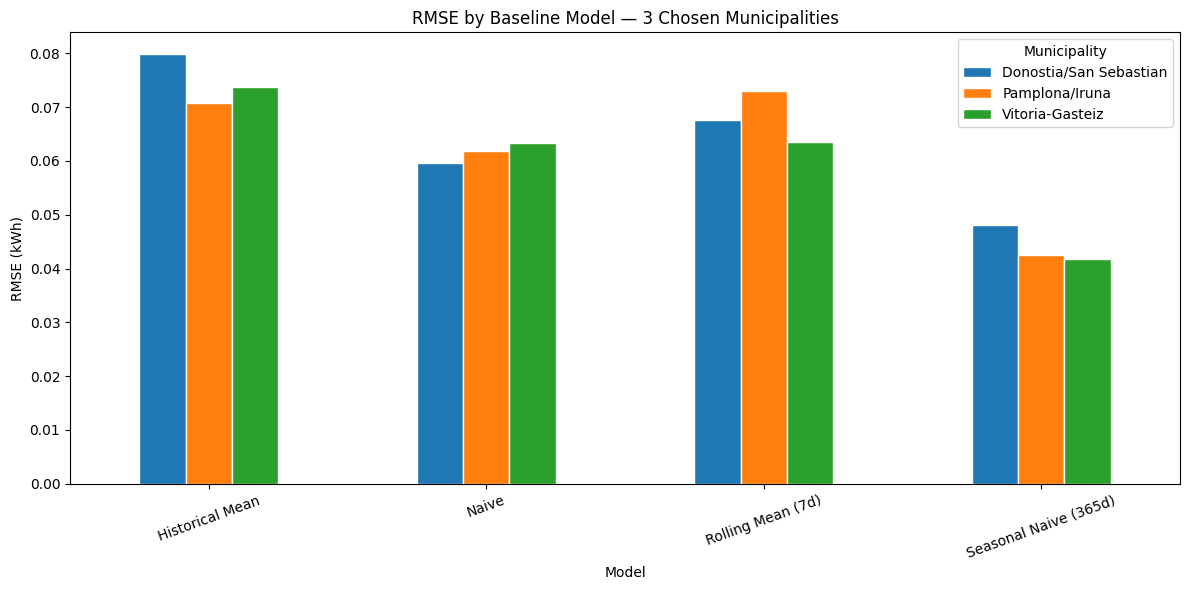


Best baseline model by RMSE per municipality:
  Vitoria-Gasteiz                → Seasonal Naive (365d)  (RMSE=0.0417)
  Donostia/San Sebastian         → Seasonal Naive (365d)  (RMSE=0.0480)
  Pamplona/Iruna                 → Seasonal Naive (365d)  (RMSE=0.0426)


In [ ]:
# ── Side-by-side metric comparison across the 3 municipalities ──────────────
comparison_rows = []
for muni in munis_to_plot:
    res = baseline_results_per_muni[muni]['results'].copy()
    res['Municipality'] = muni
    comparison_rows.append(res.reset_index())

comparison_df = pd.concat(comparison_rows, ignore_index=True)

# Pivot: Model x Municipality, metric = RMSE
pivot_rmse = comparison_df.pivot(index='Model', columns='Municipality', values='RMSE')
pivot_mae  = comparison_df.pivot(index='Model', columns='Municipality', values='MAE')
pivot_mape = comparison_df.pivot(index='Model', columns='Municipality', values='MAPE(%)')

print("RMSE per model and municipality:")
display(pivot_rmse.round(4))

print("\nMAE per model and municipality:")
display(pivot_mae.round(4))

print("\nMAPE (%) per model and municipality:")
display(pivot_mape.round(2))

# Bar chart: RMSE per model, grouped by municipality
fig, ax = plt.subplots(figsize=(12, 6))
pivot_rmse.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('RMSE by Baseline Model — 3 Chosen Municipalities')
ax.set_ylabel('RMSE (kWh)')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Municipality')
plt.tight_layout()
plt.show()

# Best model per municipality
print("\nBest baseline model by RMSE per municipality:")
for muni in munis_to_plot:
    best = baseline_results_per_muni[muni]['results']['RMSE'].idxmin()
    rmse = baseline_results_per_muni[muni]['results'].loc[best, 'RMSE']
    print(f"  {muni:<30} → {best}  (RMSE={rmse:.4f})")


### Baseline summary across all municipalities

Run every municipality through all four baselines and compare aggregated RMSE to identify which model generalises best.

Average baseline metrics across all municipalities:


,MAE,RMSE,MAPE(%)
Model,,,
Naive,0.0572,0.0711,17.440
Seasonal Naive (365d),0.0591,0.0714,15.552
Rolling Mean (7d),0.0571,0.0725,16.142
Historical Mean,0.0867,0.1036,21.988


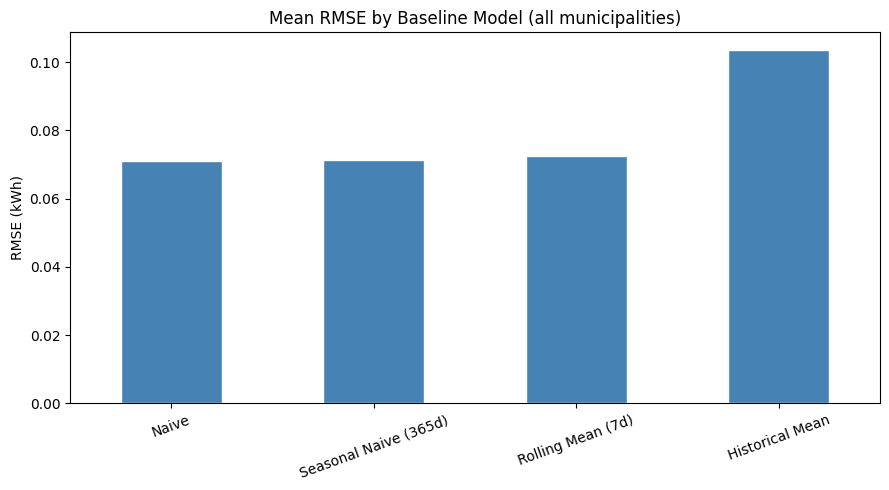

In [ ]:
all_results = []

for muni in filtered_municipality_daily['municipality'].unique():
    ts_m = (
        filtered_municipality_daily[filtered_municipality_daily['municipality'] == muni]
        [['date', 'avg_kwh']]
        .sort_values('date')
        .set_index('date')
        .asfreq('D')
        ['avg_kwh']
        .interpolate('linear')
    )
    if len(ts_m) < 60:   # skip very short series
        continue

    sp = int(len(ts_m) * 0.80)
    tr, te = ts_m.iloc[:sp], ts_m.iloc[sp:]

    preds = {
        'Naive':                 pd.Series(tr.iloc[-1], index=te.index),
        'Seasonal Naive (365d)': seasonal_naive(tr, te),
        'Rolling Mean (7d)':     pd.Series(tr.rolling(7).mean().iloc[-1], index=te.index),
        'Historical Mean':       pd.Series(tr.mean(), index=te.index),
    }

    for model_name, pred in preds.items():
        row = evaluate(te, pred, model_name)
        row['municipality'] = muni
        all_results.append(row)

all_results_df = pd.DataFrame(all_results)

summary = (
    all_results_df
    .groupby('Model')[['MAE','RMSE','MAPE(%)']]
    .mean()
    .round(4)
    .sort_values('RMSE')
)
print('Average baseline metrics across all municipalities:')
display(summary)

# Bar chart of mean RMSE per model
fig, ax = plt.subplots(figsize=(9, 5))
summary['RMSE'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Mean RMSE by Baseline Model (all municipalities)')
ax.set_ylabel('RMSE (kWh)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()